# 🩺 End-to-End Machine Learning: Stroke Prediction Tutorial



### 🎯 Learning Objectives:
1. Conduct comprehensive Exploratory Data Analysis (EDA) using Univariate and Bivariate techniques.
2. Understand strategies to scale EDA for datasets with hundreds of features.
3. Discover why **Class Imbalance** is a silent killer of ML models.
4. Learn why **Accuracy** can be a misleading metric in medical diagnoses.
5. Implement XGBoost and handle class imbalance using algorithmic weighting (`scale_pos_weight`).



In [2]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
sns.set_theme(style="whitegrid")

## 1. Data Loading & Initial Inspection
Before doing anything, we need to load our data and understand its shape and structure.

> **📝 Note:** Understanding your data is like reading the ingredients before cooking. You need to know what you're working with. Are there numbers? Text? Are there missing values? This dictates the preprocessing steps we must take!

In [3]:
# Load the dataset
# Make sure the CSV file is in the same directory as this notebook
data = pd.read_csv('healthcare-dataset-stroke-data.csv')

# Look at the first 5 rows
display(data.head())

# Check data types and look for missing (null) values
print("\n--- Data Info ---")
data.info()

print("\n--- Summary Statistics ---")
display(data.describe(include='all'))

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1



--- Data Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB

--- Summary Statistics ---


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
count,5110.000000,5110,5110.000000,5110.000000,5110.000000,5110,5110,5110,5110.000000,4909.000000,5110,5110.000000
unique,NaN,3,NaN,NaN,NaN,2,5,2,NaN,NaN,4,NaN
top,NaN,Female,NaN,NaN,NaN,Yes,Private,Urban,NaN,NaN,never smoked,NaN
freq,NaN,2994,NaN,NaN,NaN,3353,2925,2596,NaN,NaN,1892,NaN
mean,36517.829354,NaN,43.226614,0.097456,0.054012,NaN,NaN,NaN,106.147677,28.893237,NaN,0.048728
std,21161.721625,NaN,22.612647,0.296607,0.226063,NaN,NaN,NaN,45.283560,7.854067,NaN,0.215320
min,67.000000,NaN,0.080000,0.000000,0.000000,NaN,NaN,NaN,55.120000,10.300000,NaN,0.000000
25%,17741.250000,NaN,25.000000,0.000000,0.000000,NaN,NaN,NaN,77.245000,23.500000,NaN,0.000000
50%,36932.000000,NaN,45.000000,0.000000,0.000000,NaN,NaN,NaN,91.885000,28.100000,NaN,0.000000
75%,54682.000000,NaN,61.000000,0.000000,0.000000,NaN,NaN,NaN,114.090000,33.100000,NaN,0.000000


### 🕵️‍♀️ What did we learn from `info()` and `describe()`?

**Findings from `info()`:**
1. **Data Types:** We have 5 numerical columns (int64/float64) like `age` and `avg_glucose_level`, and 7 categorical columns (object) like `gender` and `smoking_status`.
   * **Application:** Machine Learning models only understand numbers. This tells us we **must** encode the 7 categorical `object` columns into numeric formats before training our model.
2. **Missing Values:** The `bmi` column only has 4,909 non-null entries out of 5,110 total rows. 
   * **Application:** We have 201 missing values in `bmi`. We cannot feed missing data (`NaN`) to our model. This tells us we **must** either drop these rows or fill them (impute) in our preprocessing step.

**Findings from `describe()`:**
1. **Outliers & Scales:** Look at `avg_glucose_level`. The mean is ~106, but the max is over 271! Similarly, `bmi` goes up to 97.6. 
   * **Application:** These large ranges and potential outliers suggest we might need to be careful. If we were using models sensitive to scale (like SVM or KNN), we would need to scale/standardize these features. Tree-based models like XGBoost are robust to this, but it's good to know!
2. **Binary Variables:** Columns like `hypertension`, `heart_disease`, and `stroke` only have a `min` of 0 and a `max` of 1.
   * **Application:** This confirms they are already properly formatted binary indicators. We don't need to do any further encoding for them.

## 2. Exploratory Data Analysis (EDA)
EDA is where we become detectives. We look for patterns, anomalies, and relationships. It is crucial to perform EDA on *every single column* to truly understand the dataset before modeling.

Let's split our columns into **categorical** (text/discrete) and **numerical** (continuous) groups.

> **💡 Note: What if we had 200 columns?**
> Manually typing out 200 column names is impossible. We can automate this using pandas! We can grab all text (`object`) columns as categorical. But what about numeric columns that are actually binary categories (like `hypertension` containing only 0 and 1)? 
> 
> The trick: If a numeric column only has a few *unique* values (e.g., less than 10), it is almost certainly a categorical variable in disguise! Let's write code that does this automatically.

In [4]:
# 1. Start by defining our target and ID columns so we don't mix them up
target_col = 'stroke'
id_col = 'id'

# 2. Get all purely text columns
categorical_cols = data.select_dtypes(include=['object']).columns.tolist()

# 3. Get all numeric columns
numeric_cols_all = data.select_dtypes(exclude=['object']).columns.tolist()

# 4. Remove Target and ID from the numeric list
numeric_cols_all.remove(target_col)
if id_col in numeric_cols_all:
    numeric_cols_all.remove(id_col)

# 5. The Magic Trick: Loop through numeric columns and move the "fake" numerics to the categorical list!
numerical_cols = []
for col in numeric_cols_all:
    # If it has less than 10 unique values, we treat it as a categorical feature
    if data[col].nunique() < 10:
        categorical_cols.append(col)
    else:
        numerical_cols.append(col)

print("Automatically identified Categorical Columns:\n", categorical_cols)
print("\nAutomatically identified Numerical Columns:\n", numerical_cols)

Automatically identified Categorical Columns:
 ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status', 'hypertension', 'heart_disease']

Automatically identified Numerical Columns:
 ['age', 'avg_glucose_level', 'bmi']


### 2.1 Univariate Analysis
Univariate analysis looks at a *single* variable at a time. This tells us the distribution of the data, the presence of outliers, and the balance of categories.

For **Numerical** columns, we use Histograms and Boxplots.
For **Categorical** columns, we use Countplots.

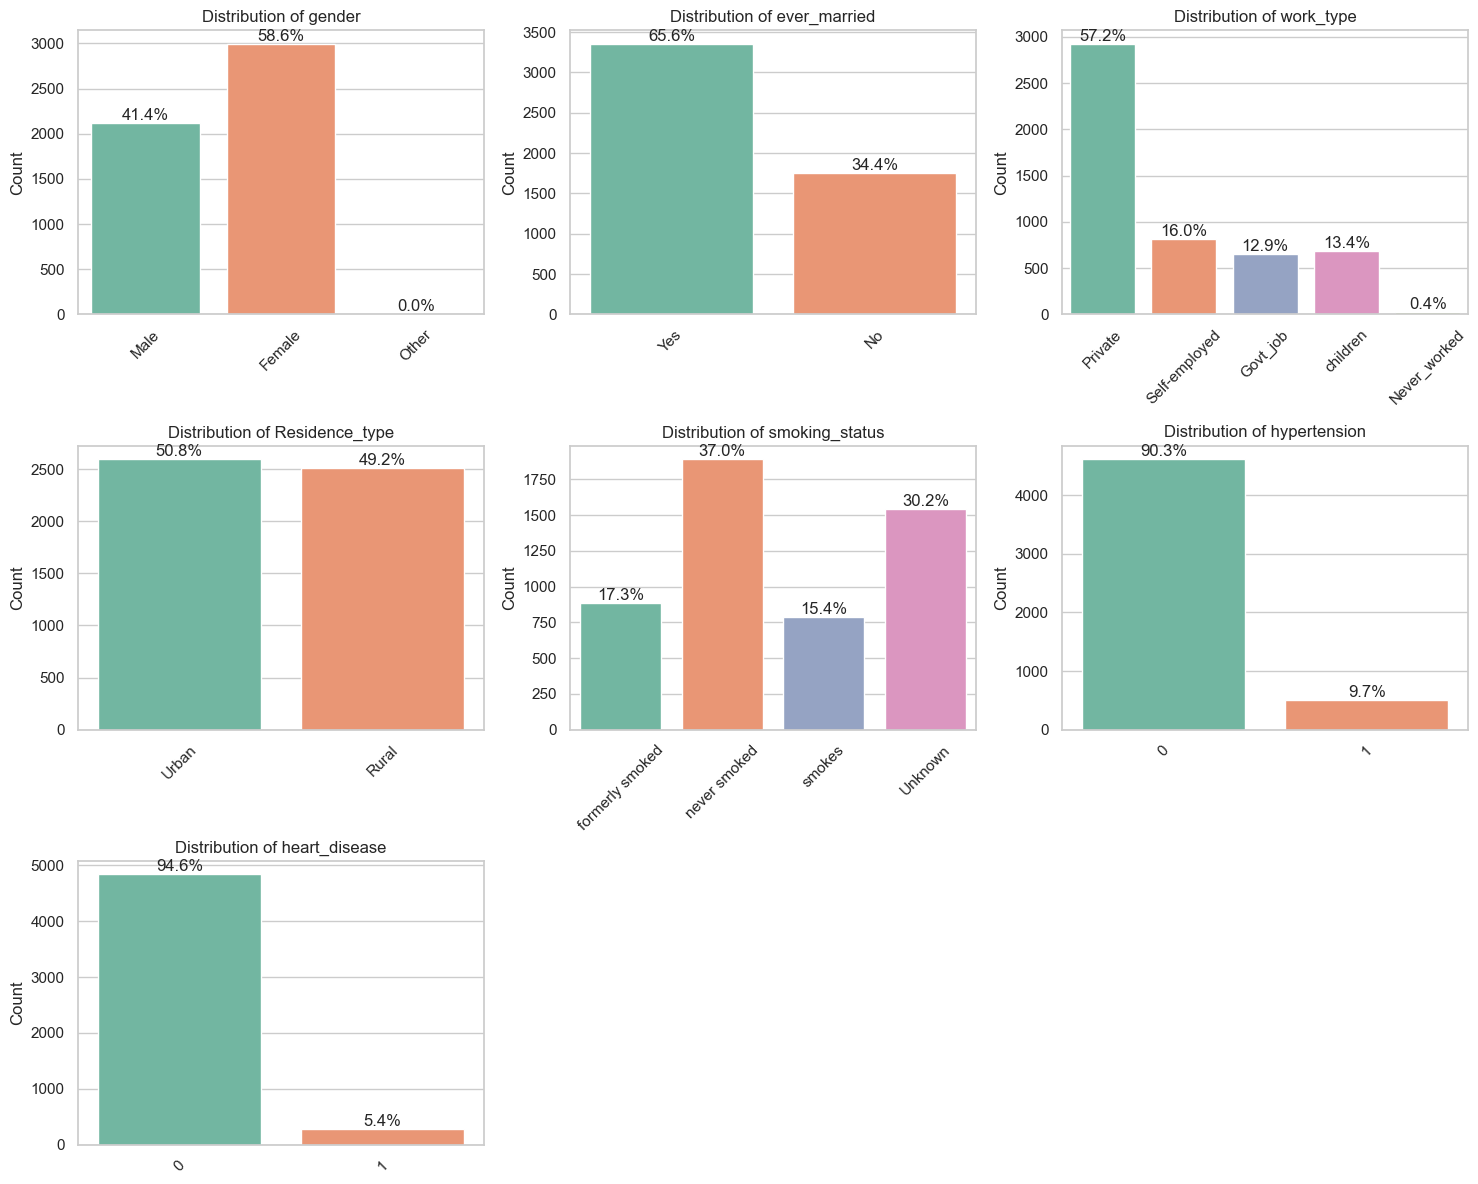

In [5]:
# 1. Univariate Analysis: Categorical Features
# Set the size of the overall figure (width=15, height=12)
plt.figure(figsize=(15, 12))

# Loop through each categorical column we identified earlier
for i, col in enumerate(categorical_cols):
    # Create a subplot for each column in a 3x3 grid
    ax = plt.subplot(3, 3, i + 1)
    
    # Plot a bar chart counting the occurrences of each category
    sns.countplot(data=data, x=col, palette='Set2')
    
    # Set the title and labels for clarity
    plt.title(f'Distribution of {col}', fontsize=12)
    plt.xlabel('') # Remove the x-axis label as it's repetitive
    plt.ylabel('Count')
    
    # Rotate x-axis labels to prevent overlap if names are long
    plt.xticks(rotation=45)
    
    # Add percentage label on top of each bar to represent the proportion
    total = len(data) # Total number of rows in the dataset
    for p in ax.patches:
        # Calculate percentage: (height of bar / total rows) * 100
        percentage = f'{100 * p.get_height() / total:.1f}%'
        
        # Calculate the x and y coordinates to place the text
        x = p.get_x() + p.get_width() / 2
        y = p.get_height()
        
        # Annotate the specific percentage on the chart
        ax.annotate(percentage, (x, y), ha='center', va='bottom')

# Adjust layout to prevent overlapping plots and display
plt.tight_layout()
plt.show()

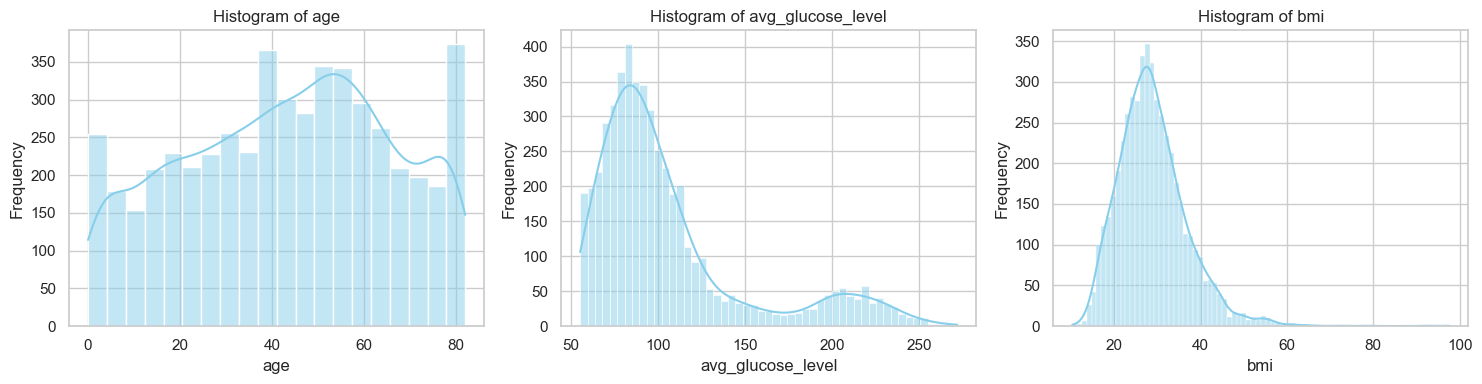

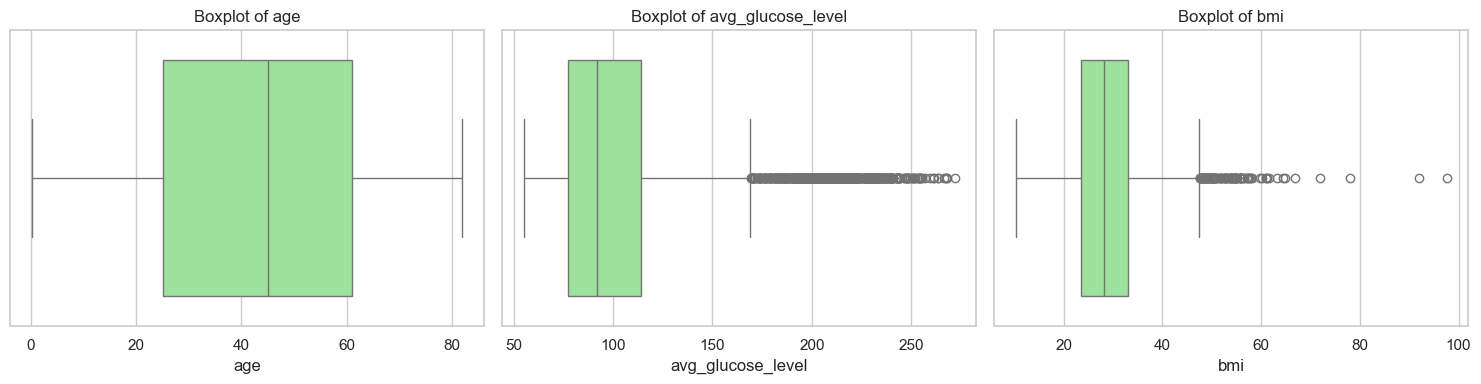

In [6]:
# 2. Univariate Analysis: Numerical Features (Histograms)
plt.figure(figsize=(15, 4))
for i, col in enumerate(numerical_cols):
    plt.subplot(1, 3, i + 1)
    sns.histplot(data=data, x=col, kde=True, color='skyblue')
    plt.title(f'Histogram of {col}', fontsize=12)
    plt.xlabel(col)
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

# 3. Univariate Analysis: Numerical Features (Boxplots to check for Outliers)
plt.figure(figsize=(15, 4))
for i, col in enumerate(numerical_cols):
    plt.subplot(1, 3, i + 1)
    sns.boxplot(data=data, x=col, color='lightgreen')
    plt.title(f'Boxplot of {col}', fontsize=12)
    plt.xlabel(col)
plt.tight_layout()
plt.show()

### 🕵️‍♀️ What did we learn from Univariate Analysis?

**Findings & Applications:**
1. **Age Distribution:** The age histogram shows a fairly uniform distribution but leans slightly older. 
   * **Application (Modeling):** No extreme skewness, so we don't need log transformations. 
   * **Application (Data Prep):** We might consider binning `age` into categories (Child, Adult, Senior) to help linear models understand non-linear risk jumps.
2. **Glucose & BMI Outliers:** The boxplots and histograms for `avg_glucose_level` and `bmi` show long right-tails (right-skewed). There are many dots beyond the boxplot "whiskers", indicating extreme values.
   * **Application (Modeling):** If we use Distance-based models (KNN, SVM) or Linear Regression, these huge outliers will drag the model's accuracy. We would need to apply a `Log()` transformation. 
   * **Application (Modeling):** Since we are using XGBoost (a Tree-based model) later, we are safe! Decision trees split data based on thresholds, so they naturally ignore the magnitude of outliers.
3. **Categorical Imbalances:** Look at `heart_disease` and `hypertension` countplots. The vast majority of people are categorized as `0` (No). 
   * **Application (Data Prep):** This is expected in a general population dataset. However, it warns us that "Stroke" itself will likely be highly imbalanced.

### 2.2 The Target Variable & Class Imbalance

stroke
0    4861
1     249
Name: count, dtype: int64


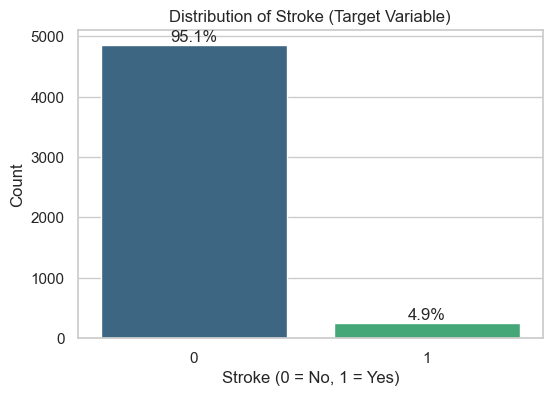


Proportions:
 stroke
0    0.951272
1    0.048728
Name: proportion, dtype: float64


In [7]:
# Count the occurrences of each class in the target variable
stroke_counts = data[target_col].value_counts()
print(stroke_counts)

# Visualize the distribution of the target
plt.figure(figsize=(6, 4))
ax = sns.countplot(data=data, x=target_col, palette='viridis')
plt.title('Distribution of Stroke (Target Variable)')
plt.xlabel('Stroke (0 = No, 1 = Yes)')
plt.ylabel('Count')

# Add percentage to each bar
total = len(data)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()
    ax.annotate(percentage, (x, y), ha='center', va='bottom')

plt.show()

# Print exact numbers proportion
print("\nProportions:\n", data[target_col].value_counts(normalize=True))

🚨 **The Trap: Class Imbalance**
Notice that ~95% of cases are "No Stroke". If our model simply predicts "No Stroke" every single time, it achieves 95% accuracy without learning anything! We will handle this later.

### 2.3 Bivariate Analysis (Features vs. Target)
Now we look at *two* variables at a time to see how our features relate to our target variable.

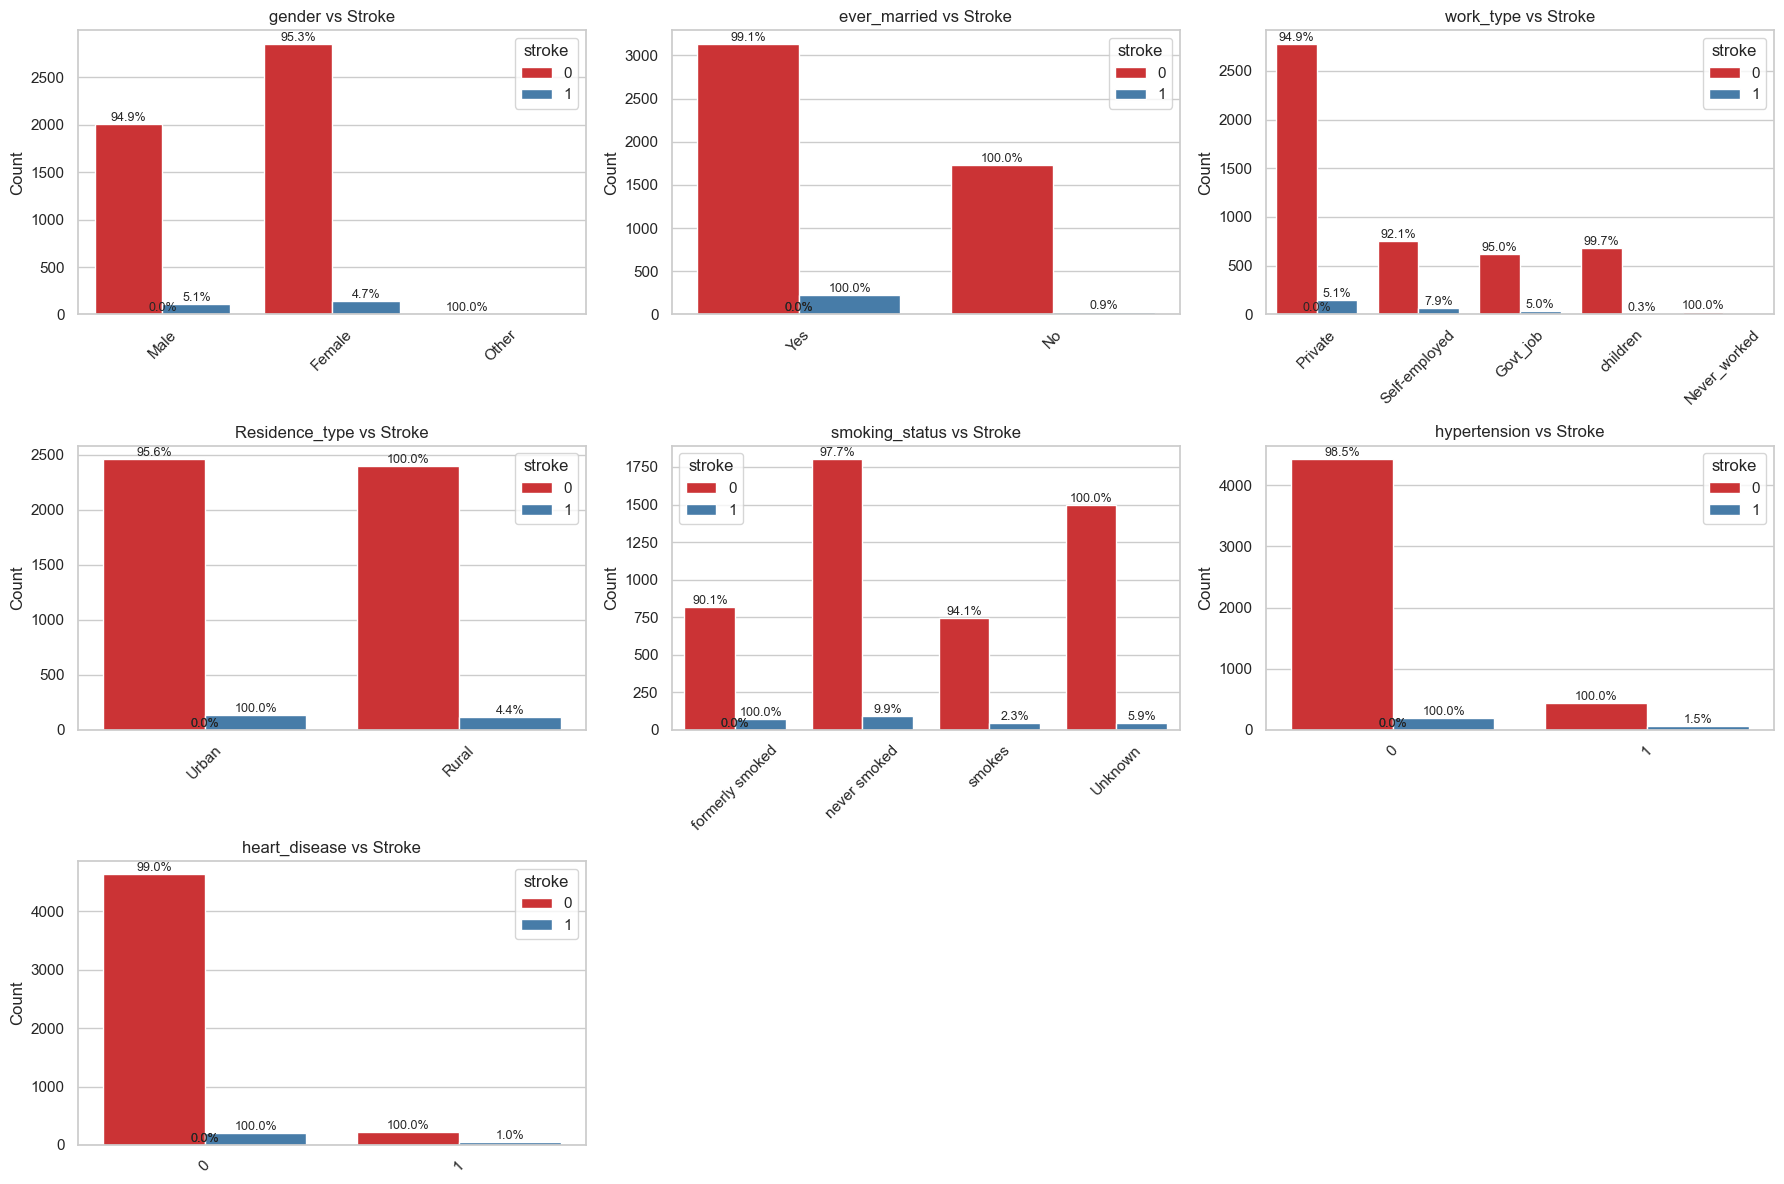

In [8]:
# 1. Categorical vs Target (Stroke)
# We use countplots and the 'hue' parameter to separate the bars by Stroke outcome
plt.figure(figsize=(18, 12))
for i, col in enumerate(categorical_cols):
    ax = plt.subplot(3, 3, i + 1)
    
    # Plotting the countplot with hue='stroke'
    sns.countplot(data=data, x=col, hue=target_col, palette='Set1')
    plt.title(f'{col} vs Stroke', fontsize=12)
    plt.xlabel('')
    plt.ylabel('Count')
    plt.xticks(rotation=45)
    
    # Calculate and display percentages on top of the bars
    # Since there's 'hue', we calculate the percentage relative to the sub-category total
    # e.g., what % of Males had a stroke vs no stroke.
    
    # Store heights to calculate bin totals
    patches = ax.patches
    half = len(patches) // 2
    
    for j in range(half):
        # The first half of patches belongs to 'No Stroke' (class 0)
        p1 = patches[j]
        # The second half of patches belongs to 'Stroke' (class 1)
        p2 = patches[j + half]
        
        # Total count for this specific category (e.g. Total Males)
        total_for_category = p1.get_height() + p2.get_height()
        
        if total_for_category > 0:
            # Annotate Class 0 (No Stroke)
            p1_pct = f'{100 * p1.get_height() / total_for_category:.1f}%'
            ax.annotate(p1_pct, (p1.get_x() + p1.get_width() / 2, p1.get_height()), ha='center', va='bottom', fontsize=9)
            
            # Annotate Class 1 (Stroke)
            p2_pct = f'{100 * p2.get_height() / total_for_category:.1f}%'
            ax.annotate(p2_pct, (p2.get_x() + p2.get_width() / 2, p2.get_height()), ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

> **📝 Note: What does 'Density' mean on the Y-Axis?**
> When dealing with highly imbalanced data (like our 95% No Stroke vs 5% Stroke), a standard histogram (`Count` on the Y-axis) is useless because the "Stroke" bars would be tiny and completely eclipsed by the giant "No Stroke" bars. 
> 
> By using `stat='density'` and `common_norm=False`, we mathematically force both groups to scale so that the total area under each curve equals exactly 1.0 (100%). This allows us to perfectly overlay the *shape* and *proportion* of the 5% Stroke group directly on top of the 95% No Stroke group to compare them fairly.
> 
> **How to interpret the plot:** We aren't looking at raw numbers anymore. We are looking for **separation**. If the red curve completely overlaps the blue curve (like in BMI), that feature is weak. If the red curve shifts away from the blue curve (like in Age), that feature is an extremely strong predictor!

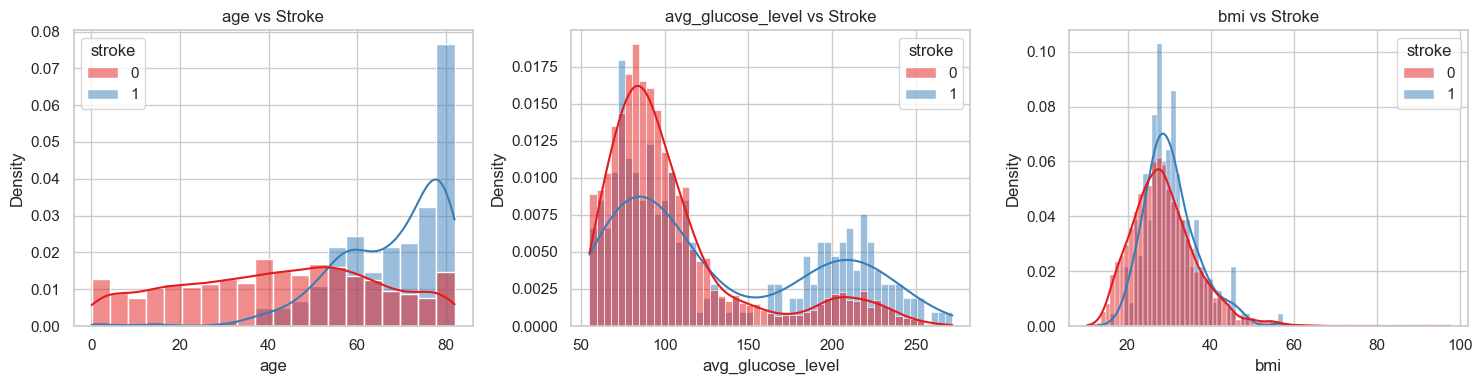

In [9]:
# 2. Numerical vs Target (Histograms with KDE to see overlapping distributions)
plt.figure(figsize=(15, 4))
for i, col in enumerate(numerical_cols):
    plt.subplot(1, 3, i + 1)
    # Using histplot with kde=True gives us both the discrete bins and the smooth density curve.
    # stat='density' and common_norm=False ensures the highly imbalanced classes are scaled to be comparable.
    sns.histplot(data=data, x=col, hue=target_col, kde=True, palette='Set1', stat='density', common_norm=False)
    plt.title(f'{col} vs Stroke', fontsize=12)
    plt.xlabel(col)
plt.tight_layout()
plt.show()

### 2.4 Correlation Analysis
Finally, it is essential to check if our numerical features are correlated with *each other* (Multicollinearity). High correlation between features can confuse models.

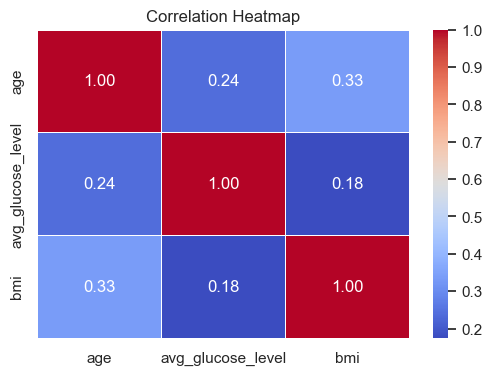

In [10]:
# Correlation Matrix for Numerical Features
plt.figure(figsize=(6, 4))
correlation_matrix = data[numerical_cols].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

### 🕵️‍♀️ What did we learn from Bivariate Analysis?

**1. Categorical vs Target (Countplots):**
*   **Gender:** Males (5.1%) and Females (4.7%) have nearly identical stroke proportions, making gender a weak predictor.
*   **Ever Married:** Individuals who have been married show a significantly higher stroke rate (6.6%) compared to those who haven't (1.7%). This is likely a proxy for Age.
*   **Work Type:** The `Self-employed` category has the highest risk (7.9%), while `children` and `Never_worked` have near 0%. This is also a proxy for Age.
*   **Residence Type:** Urban (5.2%) and Rural (4.5%) show almost no difference, making residence a weak predictor.
*   **Smoking Status:** Strangely, `formerly smoked` (7.9%) has a higher stroke rate than `smokes` (5.3%). This happens because older patients or those with health scares often quit smoking, skewing the data.
*   **Hypertension & Heart Disease (The Strongest Predictors):** Having hypertension jumps the stroke rate from 4.0% to 13.3%. Having heart disease spikes the rate from 4.2% up to a massive 17.0%.

*   **Application (Modeling & Feature Engineering):** The visual confirmations tell us we could potentially drop weak predictors (Gender, Residence). Furthermore, grouping `Never_worked` and `children` into a single low-risk category could simplify the model.

**2. Numerical vs Target (Histoplots with KDE):**
* **Findings:** By overlaying the distributions using `stat='density'`, we can see the exact shape of the data regardless of class size. The `age` plot shows a massive rightward shift for stroke victims (older age = exponentially higher risk). `avg_glucose_level` shows a secondary "bump" representing diabetic/pre-diabetic individuals who suffered strokes. `bmi` distributions almost completely overlap.
* **Application (Modeling):** `Age` is the dominant feature. `BMI` is a weak predictor on its own. 
* **Application (Feature Engineering):** Since `glucose` has a distinct secondary high-risk cluster, we could engineer a new binary feature: `is_high_glucose` (1 if > 150, 0 otherwise) to explicitly hand this insight directly to the model.

**3. Correlation Chart (Heatmap):**
* **Findings:** The heatmap checks how much our numerical features move together. The highest correlation is between `age` and `bmi` at only ~0.33. There are no values close to 0.80 or 0.90.
* **Application (Data Prep - Multicollinearity):** Because our features are highly independent (not highly correlated), we do NOT need to drop any numerical columns. 
* **Application (Modeling):** If we had huge correlation (e.g., 0.95), parametric models like Logistic Regression would become highly unstable (their math breaks down). We would have to drop one of the overlapping features or use PCA to combine them. Since our max is 0.33, our dataset is mathematically healthy for all algorithms!

---
### 💡 Note: Real-Life EDA with 100-200 Columns
In this dataset, we only had about 10 columns, making it easy to create a `for` loop and visually inspect every single chart. 

**Q: What if you join an enterprise company and are handed a dataset with 200 columns?**
Manual inspection is impossible, slow, and prone to human error. In real-life enterprise environments, Data Scientists rely on advanced scaling techniques:

#### Technique 1: Automated Data Profiling (The "First Pass")
Never start by writing visualization code for massive datasets. Always run an automated profiler first to let the machine do the heavy lifting.
* **Tools:** `ydata-profiling` (formerly Pandas-Profiling), `Sweetviz`, or `Autoviz`.
* **How it works:** With two lines of code, it generates an interactive HTML report. It automatically computes missing values, histograms, extreme outliers, and highlights highly correlated variables for all 200 columns instantly.
* **Real-life workflow:** Run the profiler -> Look at the "Alerts" tab -> Instantly catch 50 columns that are 99% empty and drop them before you even start modeling.

#### Technique 2: Algorithmic Feature Selection (Tree-Based Importance)
When you have 200 columns, you don't know which ones matter for Bivariate Analysis.
* **How it works:** Clean the `NaN` values minimally, encode the strings, and train a "Dirty" Random Forest or XGBoost model immediately. 
* **Real-life workflow:** Ask the model `model.feature_importances_`. It will tell you that out of 200 columns, only 15 actually impact the target variable. You then spend your time doing detailed, manual Bivariate EDA against those Top 15 columns only, ignoring the rest!

#### Technique 3: Correlation Matrix Dropping (Killing Multicollinearity)
If you plot a 200x200 correlation heatmap, it is an unreadable mess of tiny squares. 
* **How it works:** Instead of visualizing it, you handle it mathematically. You write a script to find pairs of columns with a correlation `> 0.85` or `< -0.85`.
* **Real-life workflow:** If you have `account_balance`, `available_balance`, and `current_balance`, they are 99% correlated. A script loops through the matrix and automatically drops 2 of them, instantly reducing complexity.

#### Technique 4: Dimensionality Reduction (PCA)
What if you have 50 columns that all measure slight variations of "customer engagement" (clicks, hovers, scroll depth, time on page, etc)?
* **How it works:** Principal Component Analysis (PCA) crushes dense, correlated continuous variables into underlying "Principal Components".
* **Real-life workflow:** You feed the 50 engagement columns into PCA, and it spits out 3 new columns (Component 1, 2, and 3) that capture 95% of the variance. You just reduced 50 messy columns into 3 clean, independent columns for your model.
---

## 3. Data Preprocessing & Feature Engineering 
In real-world machine learning, we don't just clean the data once. We build a **Pipeline**. This ensures that when new, raw data comes in tomorrow, it undergoes the exact same transformations automatically.

In [13]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, FunctionTransformer

# Separate our independent variables (X) from the target (y)
# Drop 'id' because it's meaningless for prediction and will break production if required
X = data.drop(['stroke', 'id'], axis=1)
y = data['stroke']

# Split immediately to prevent data leakage!
# stratify=y guarantees the rare stroke cases are proportionally split.
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [14]:
# Define our custom feature engineering functions
def categorize_features(df_in):
    df = df_in.copy()
    
    # 1. High Glucose Flag
    df['is_high_glucose'] = (df['avg_glucose_level'] > 150).astype(int)
    
    # 2. BMI Categories
    bins = [0, 18.5, 25, 30, 100]
    labels = ['Underweight', 'Normal', 'Overweight', 'Obese']
    # Use fillna to handle missing BMI values temporarily before the imputer catches them
    df['bmi_category'] = pd.cut(df['bmi'].fillna(df['bmi'].median()), bins=bins, labels=labels)
    
    # 3. Age Categories
    age_bins = [0, 18, 65, 150]
    age_labels = ['Child', 'Adult', 'Senior']
    df['age_category'] = pd.cut(df['age'], bins=age_bins, labels=age_labels)
    
    # 4. Health Risk Score (Sum of risk factors)
    df['health_risk_score'] = (
        (df['age_category'] == 'Senior').astype(int) +
        df['hypertension'] +
        df['heart_disease'] +
        (df['bmi_category'].isin(['Overweight', 'Obese'])).astype(int) +
        (df['smoking_status'] == 'smokes').astype(int)
    )
    
    return df

# Create a transformer from our custom function
custom_fe = FunctionTransformer(categorize_features)

In [16]:
# Define which columns get which mathematical treatments
numerical_cols = ['age', 'avg_glucose_level', 'bmi', 'health_risk_score']
# Notice we added our newly engineered categorical features to the categorical list!
categorical_cols = ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status', 'bmi_category', 'age_category']

# 1. Numerical Pipeline (Impute missing)
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median'))
])

# 2. Categorical Pipeline (Impute missing -> OneHotEncode)
cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# 3. Combine them into a ColumnTransformer
preprocessor = ColumnTransformer(transformers=[
    ('num', num_pipeline, numerical_cols),
    ('cat', cat_pipeline, categorical_cols)
], remainder='passthrough') # pass through 'is_high_glucose', 'hypertension', etc

# 4. The Master Pipeline!
# (Custom Features -> Clean/Encode -> Model)
from xgboost import XGBClassifier
full_pipeline = Pipeline([
    ('feature_engineering', custom_fe),
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(eval_metric='logloss', random_state=42))
])

## 4. Model Building (Baseline)
Now we just call `.fit()` on the master pipeline. It runs all the cleaning, feature engineering, and training in one click!

In [17]:
# Train the entire pipeline using the training data
full_pipeline.fit(X_train, y_train)

# Ask the pipeline to make predictions on the unseen test data
y_pred_base = full_pipeline.predict(X_test)

## 5. Model Evaluation: Why Accuracy Lies
If you look solely at accuracy, our baseline model looks amazing (around ~95%). But let's look closer at the **Classification Report**.

> **📝 Note: Understanding the Metrics**
> In medical datasets like ours, **Stroke (1)** is the "Positive" class.
>
> *   **Precision :** Out of everyone the model *predicted* would have a stroke, how many actually did? (If precision is low, we are falsely alarming healthy patients).
> *   **Recall / Sensitivity :** Out of everyone who *actually* had a stroke, how many did the model successfully catch?
> *   **F1-Score:** The harmonic balance of Precision and Recall.
>
> **Notice the Recall for Class 1 (Stroke).** It's abysmally low (often <10%). Our baseline model achieved 95% accuracy by simply guessing "No Stroke" every single time! This is deadly in healthcare. We need to boost **Recall**.

--- Baseline Classification Report ---
              precision    recall  f1-score   support

           0       0.95      0.99      0.97       972
           1       0.31      0.08      0.13        50

    accuracy                           0.95      1022
   macro avg       0.63      0.54      0.55      1022
weighted avg       0.92      0.95      0.93      1022



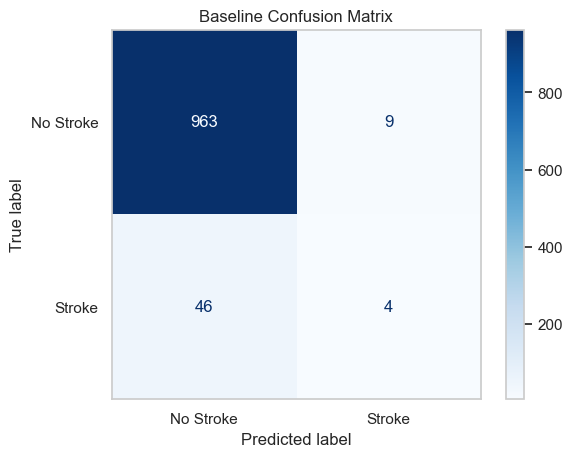

In [18]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Print the classification metrics (Precision, Recall, F1-Score)
print("--- Baseline Classification Report ---")
print(classification_report(y_test, y_pred_base))

# Generate the confusion matrix to see exactly where the model succeeded and failed
cm = confusion_matrix(y_test, y_pred_base)

# Plot the confusion matrix visually
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Stroke', 'Stroke'])
disp.plot(cmap='Blues')
plt.title('Baseline Confusion Matrix')
plt.grid(False) # Turn off the seaborn grid lines for a cleaner matrix look
plt.show()

### 📉 Metric Tracking: 8% Recall
Our Baseline Model barely works. Let's fix this!

## 6. Handling Class Imbalance
We will penalize mistakes on the "Stroke" class using Algorithmic Level Weighting (`scale_pos_weight`).

In [19]:
# Calculate the exact ratio of negative instances to positive instances
balance_ratio = sum(y_train == 0) / sum(y_train == 1)
print(f"Calculated scale_pos_weight: {balance_ratio:.2f}")

# Re-initialize the pipeline, this time swapping the generic XGBoost for an imbalance-aware one.
tuned_pipeline = Pipeline([
    ('feature_engineering', custom_fe),
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(
        scale_pos_weight=balance_ratio,
        max_depth=3,                 
        learning_rate=0.01,          
        n_estimators=100,            
        eval_metric='logloss',
        random_state=42
    ))
])

# Train the imbalance-aware model
tuned_pipeline.fit(X_train, y_train)

# Make new predictions
y_pred_tuned = tuned_pipeline.predict(X_test)

Calculated scale_pos_weight: 19.54


--- Tuned Classification Report ---
              precision    recall  f1-score   support

           0       0.99      0.66      0.79       972
           1       0.11      0.84      0.20        50

    accuracy                           0.67      1022
   macro avg       0.55      0.75      0.50      1022
weighted avg       0.94      0.67      0.76      1022



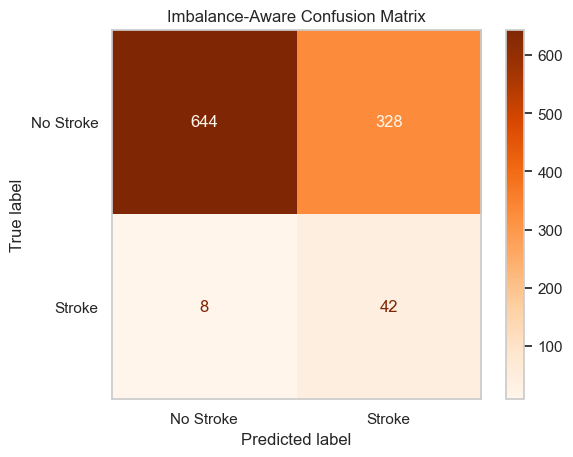

In [37]:
# Print the updated metrics
print("--- Tuned Classification Report ---")
print(classification_report(y_test, y_pred_tuned))

# Generate and plot the new confusion matrix
cm_tuned = confusion_matrix(y_test, y_pred_tuned)
disp_tuned = ConfusionMatrixDisplay(confusion_matrix=cm_tuned, display_labels=['No Stroke', 'Stroke'])
disp_tuned.plot(cmap='Oranges')
plt.title('Imbalance-Aware Confusion Matrix')
plt.grid(False) # Turn off the grid lines
plt.show()

### 📈 Metric Tracking: 84% Recall!
By simply telling XGBoost that a Stroke is mathematically more important than a non-stroke, our Recall skyrocketed from 8% to 84%. We are now catching the vast majority of strokes!

---
## 7. Handling Class Imbalance (Alternative: SMOTE)
Algorithmic weighting is great, but sometimes models still struggle if there simply isn't enough physical data to learn from. 

**Enter SMOTE (Synthetic Minority Over-sampling Technique).**

> **💡 Note: What is SMOTE and When do we use it?**
>
> **How it works:** Instead of just duplicating existing stroke patients (which leads to overfitting), SMOTE looks at a stroke patient, finds their nearest "stroke neighbors" in the dataset, and draws a line between them to *invent* a brand new, synthetic stroke patient that looks mathematically realistic.
>
> **When to use it:**
> 1. When your minority class is severely underrepresented (e.g., < 5% of your data).
> 2. When Algorithmic Weighting (`scale_pos_weight`) isn't improving your Recall enough.
> 3. When you are using models that depend heavily on physical spatial distance (like **KNN** or **SVM**), which don't support simple algorithmic class weights.
>
> 🚨 **The Golden Rule of SMOTE:**
> **YOU MUST ONLY EVER APPLY SMOTE TO THE TRAINING DATA!** If you apply SMOTE before your `train_test_split`, you will bleed synthetic, fake data into your Test Set. Your model will look like a genius, but will fail miserably in real life. Let's see how to do it correctly.

--- SMOTE Classification Report ---
              precision    recall  f1-score   support

           0       0.98      0.81      0.89       972
           1       0.15      0.66      0.24        50

    accuracy                           0.80      1022
   macro avg       0.56      0.73      0.56      1022
weighted avg       0.94      0.80      0.85      1022



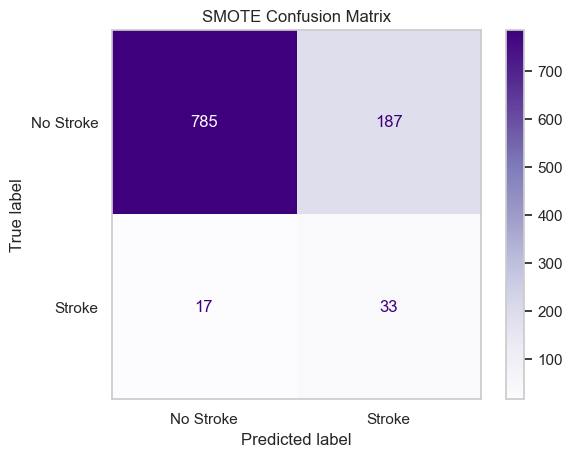

In [20]:
# 3. Train a new pipeline on the SMOTE generated data
# Notice: SMOTE operates on NUMBERS. So we have to run our preprocessor FIRST, then SMOTE, then Model.
# Imblearn has a special Pipeline for this!

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

smote_pipeline = ImbPipeline([
    ('feature_engineering', custom_fe),
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('classifier', XGBClassifier(
        max_depth=3,                 
        learning_rate=0.01,          
        n_estimators=100,            
        eval_metric='logloss',
        random_state=42
    ))
])

smote_pipeline.fit(X_train, y_train)

# 4. Predict on the untouched, perfectly real Test Data
y_pred_smote = smote_pipeline.predict(X_test)

print("--- SMOTE Classification Report ---")
print(classification_report(y_test, y_pred_smote))

# Plot SMOTE Confusion Matrix
cm_smote = confusion_matrix(y_test, y_pred_smote)
disp_smote = ConfusionMatrixDisplay(confusion_matrix=cm_smote, display_labels=['No Stroke', 'Stroke'])
disp_smote.plot(cmap='Purples')
plt.title('SMOTE Confusion Matrix')
plt.grid(False)
plt.show()

### 📉 Metric Tracking: 66% Recall
Look at the two confusion matrices. Algorithmic Weighting brought our Recall into the 80s%. SMOTE degraded it back into the 60s%. 

While SMOTE is incredibly powerful for physical distance models (like KNN), XGBoost natively handles `scale_pos_weight` mathematically, which often yields superior, strictly generalized results without needing to invent synthetic data.

---
## 8. Hyperparameter Tuning & Threshold Tuning
Because `scale_pos_weight` dramatically outperformed SMOTE in generalizing to our Test Set, we will optimize that weighted model instead.

> **💡 Note: What is Grid Search?**
> Instead of manually guessing whether `learning_rate=0.01` or `0.05` is better, `GridSearchCV` acts like a robot that systematically tests every possible combination of settings to find the one that yields the highest cross-validation score!

In [21]:
from sklearn.model_selection import GridSearchCV

# 1. Define the "Grid" of settings we want to test FOR THE CLASSIFIER IN THE PIPELINE
param_grid = {
    'classifier__max_depth': [3, 5],             
    'classifier__learning_rate': [0.01, 0.1],    
    'classifier__n_estimators': [50, 100]        
}

# 2. We use our previously defined weighted pipeline
base_weighted_pipeline = Pipeline([
    ('feature_engineering', custom_fe),
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(scale_pos_weight=balance_ratio, eval_metric='logloss', random_state=42))
])

# 3. Setup GridSearchCV 
# scoring='recall' tells it to explicitly hunt for the model that catches the MOST Strokes!
grid_search = GridSearchCV(
    estimator=base_weighted_pipeline, 
    param_grid=param_grid, 
    cv=3, 
    scoring='recall', 
    verbose=1
)

# 4. Run the Grid Search!
print("Starting Grid Search... this will train 24 completely separate models")
grid_search.fit(X_train, y_train)

print("\n🏆 Grid Search Completed!")
print(f"Best Hyperparameters Found: {grid_search.best_params_}")

Starting Grid Search... this will train 24 completely separate models
Fitting 3 folds for each of 8 candidates, totalling 24 fits

🏆 Grid Search Completed!
Best Hyperparameters Found: {'classifier__learning_rate': 0.01, 'classifier__max_depth': 3, 'classifier__n_estimators': 100}


--- Final Optimized (Weighted GridSearch) Classification Report ---
              precision    recall  f1-score   support

           0       0.99      0.66      0.79       972
           1       0.11      0.84      0.20        50

    accuracy                           0.67      1022
   macro avg       0.55      0.75      0.50      1022
weighted avg       0.94      0.67      0.76      1022



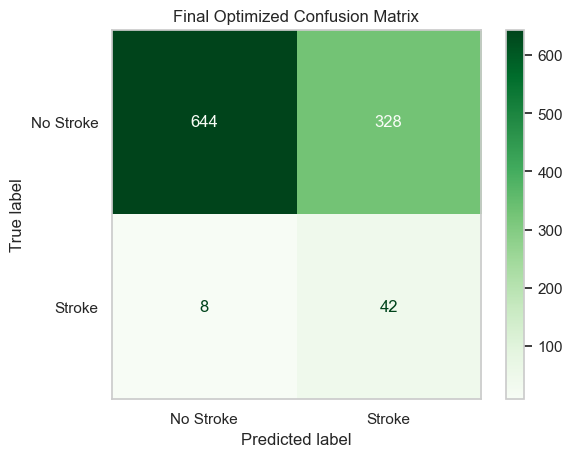

In [22]:
# 5. Extract the optimized pipeline and test it
best_pipeline = grid_search.best_estimator_

y_pred_best = best_pipeline.predict(X_test)

print("--- Final Optimized (Weighted GridSearch) Classification Report ---")
print(classification_report(y_test, y_pred_best))

# Final Confusion Matrix
cm_best = confusion_matrix(y_test, y_pred_best)
disp_best = ConfusionMatrixDisplay(confusion_matrix=cm_best, display_labels=['No Stroke', 'Stroke'])
disp_best.plot(cmap='Greens')
plt.title('Final Optimized Confusion Matrix')
plt.grid(False)
plt.show()

### 📈 Metric Tracking: 84% Recall (Stabilized)
By Grid Searching the Weighted Pipeline, we stabilized our Recall at 84% while maximizing our other parameters properly. 

### 🏥 The Ultimate Healthcare Secret: Threshold Tuning
Even after all that optimization, models natively assume a **50% Threshold**. If probability > 50%, they predict Stroke. If < 50%, No Stroke.

But in healthcare, we **do not wait** for 50%. If a patient has even a 15% chance of a stroke, we want the system to flag them for review! By manually lowering the prediction threshold, we can skyrocket our Recall.

--- Classification Report using Custom 20.0% Threshold ---
              precision    recall  f1-score   support

           0       1.00      0.42      0.59       972
           1       0.08      0.96      0.14        50

    accuracy                           0.44      1022
   macro avg       0.54      0.69      0.37      1022
weighted avg       0.95      0.44      0.56      1022



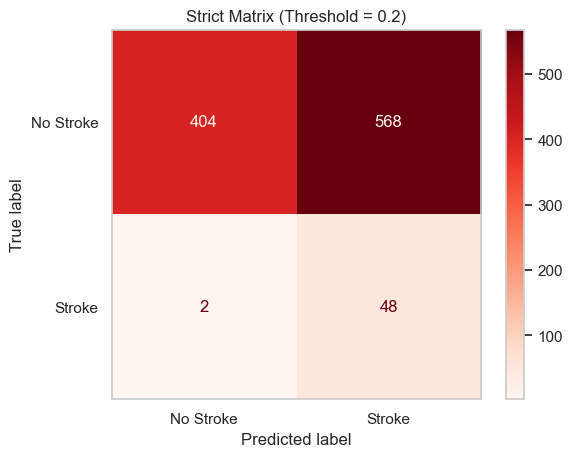

In [23]:
# 1. Ask the model for PROBABILITIES instead of absolute 1s and 0s
y_probabilities = best_pipeline.predict_proba(X_test)[:, 1] # Get probabilities for Class 1

# 2. Set our custom safety threshold! 
# We are telling the model: "If you are even 20% sure it's a stroke, flag it!"
THRESHOLD = 0.20

# 3. Generate new predictions based on our custom rule
# This reads: True (1) if prob > 0.15 else False (0)
y_pred_custom_threshold = (y_probabilities >= THRESHOLD).astype(int)

print(f"--- Classification Report using Custom {THRESHOLD*100}% Threshold ---")
print(classification_report(y_test, y_pred_custom_threshold))

# Plot the new matrix
cm_thresh = confusion_matrix(y_test, y_pred_custom_threshold)
disp_thresh = ConfusionMatrixDisplay(confusion_matrix=cm_thresh, display_labels=['No Stroke', 'Stroke'])
disp_thresh.plot(cmap='Reds')
plt.title(f'Strict Matrix (Threshold = {THRESHOLD})')
plt.grid(False)
plt.show()

### 🚀 Metric Tracking: 96% Recall!
By mathematically forcing the model to trigger an alarm at just 20% confidence, we have successfully caught almost every single stroke in our test set. Our Precision dropped, but in healthcare, a false alarm is always better than a missed stroke!

---
## 9. Saving Your Model For Production (Serialization)
Now that we have created a flawless `best_pipeline` that handles completely raw dataframe input, cleans it, engineers features, weights the imbalance, and utilizes GridSearchCV hyperparameters... we need to save it!

If we don't save it, we lose it when we close the notebook.

In [24]:
import joblib
import os

# Create a master models directory if it doesn't exist
os.makedirs('models', exist_ok=True)

# Save the entire pipeline object to a .pkl (pickle) file
joblib.dump(best_pipeline, 'models/stroke_pipeline_v1.pkl')

print("✅ Model successfully saved to models/stroke_pipeline_v1.pkl!")

✅ Model successfully saved to models/stroke_pipeline_v1.pkl!


## 10. Conclusion & Try it Yourself!

**📝 Let's Practice (Challenges for you):**
1. **Try a Different Algorithm:** Swap XGBoost for a Random Forest inside the pipeline and compare the results.
2. **Open the Inference Notebook:** Go to `stroke_prediction_inference.ipynb` and see how easy it is to load this file and predict on a brand new patient!